# Breast Cancer Wisconsin 
EDA & Visualizations 

# Objectives
1.Perform **Univariate Analysis** — distribution of individual features
2. Perform **Bivariate Analysis** — Benign vs Malignant comparisons 
3. Perform **Multivariate Analysis** — correlations and combined patterns 
4. Derive **5+ key medical insights** from the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'font.size'       : 11,
})
COLORS = {'B': '#4CAF50', 'M': '#F44336'}
print("✅ Libraries loaded!")

✅ Libraries loaded!



Load wdbc_cleaned.csv

In [2]:
df = pd.read_csv(r'C:\Users\Christy Anna\Desktop\ENTRI\DA\breast+cancer+wisconsin+diagnostic\wdbc_cleaned.csv')

df['cancer_type']         = df['cancer_type'].astype('category')
df['tumor_size_category'] = pd.Categorical(df['tumor_size_category'],
                             categories=['Small','Medium','Large','Very Large'], ordered=True)
df['surface_smoothness']  = pd.Categorical(df['surface_smoothness'],
                             categories=['Low','Moderate','High'], ordered=True)

avg_cols       = [c for c in df.columns if c.startswith('avg_')]
variation_cols = [c for c in df.columns if c.startswith('variation_')]
worst_cols     = [c for c in df.columns if c.startswith('worst_')]
feature_cols   = avg_cols + variation_cols + worst_cols

print(f"✅ Cleaned dataset loaded!")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nCancer Type Distribution:")
print(df['cancer_type'].value_counts())
df.head()

✅ Cleaned dataset loaded!
   Shape : 569 rows × 39 columns

Cancer Type Distribution:
cancer_type
B    357
M    212
Name: count, dtype: int64


,patient_id,cancer_type,avg_cell_radius,avg_cell_texture,avg_cell_perimeter,avg_cell_area,avg_cell_smoothness,avg_cell_compactness,avg_cell_concavity,avg_concave_points,...,worst_cell_concave_points,worst_cell_symmetry,worst_cell_fractal_dimension,cancer_diagnosis,shape_irregularity,radius_growth_factor,area_growth_factor,total_concavity_score,tumor_size_category,surface_smoothness
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,0.2654,0.4601,0.11890,1,15.0648,1.4108,2.0170,1.0120,Very Large,High
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,0.1860,0.2750,0.08902,1,13.3201,1.2149,1.4751,0.3285,Very Large,Moderate
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,0.2430,0.3613,0.08758,1,14.0482,1.1971,1.4206,0.6478,Very Large,High
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,0.2575,0.6638,0.17300,1,15.5883,1.3056,1.4703,0.9283,Small,High
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,0.1625,0.2364,0.07678,1,14.0725,1.1109,1.2143,0.5980,Very Large,High



# 📊 Section 1: Univariate Analysis
# Visualization 1: Cancer Type Distribution 
First we check how many patients have Benign vs Malignant tumors.
This tells us if the dataset is balanced or skewed important before doing any further analysis.

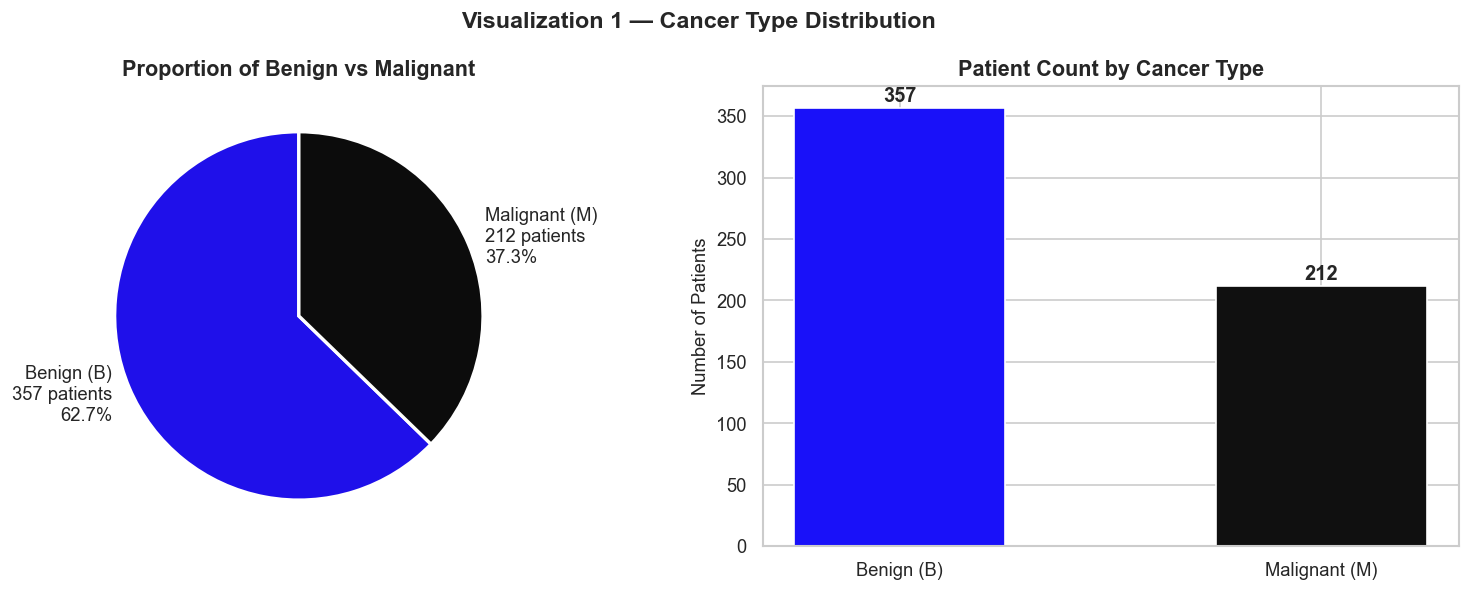

Benign    : 357 (62.7%)
Malignant : 212 (37.3%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Visualization 1 — Cancer Type Distribution",
             fontsize=14, fontweight='bold')

# Pie chart
counts = df['cancer_type'].value_counts()
labels = [f"Benign (B)\n{counts['B']} patients\n{counts['B']/len(df)*100:.1f}%",
          f"Malignant (M)\n{counts['M']} patients\n{counts['M']/len(df)*100:.1f}%"]
axes[0].pie(counts, labels=labels,
            colors=["#1F10EA","#0C0C0C"],
            startangle=90, autopct='',
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title("Proportion of Benign vs Malignant")

# Bar chart
bars = axes[1].bar(['Benign (B)','Malignant (M)'],
                   [counts['B'], counts['M']],
                   color=["#1911F9","#101010"],
                   edgecolor='white', width=0.5)
axes[1].set_title("Patient Count by Cancer Type")
axes[1].set_ylabel("Number of Patients")
for bar, val in zip(bars, [counts['B'], counts['M']]):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5, str(val),
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz1_cancer_distribution.png', bbox_inches='tight')
plt.show()
print(f"Benign    : {counts['B']} ({counts['B']/len(df)*100:.1f}%)")
print(f"Malignant : {counts['M']} ({counts['M']/len(df)*100:.1f}%)")


# Visualization 2: Distribution of Cell Radius and Area
 Histograms show how measurements are spread across all patients.
 A right-skewed shape means most patients have small values but a few have very large values — typical in cancer data.

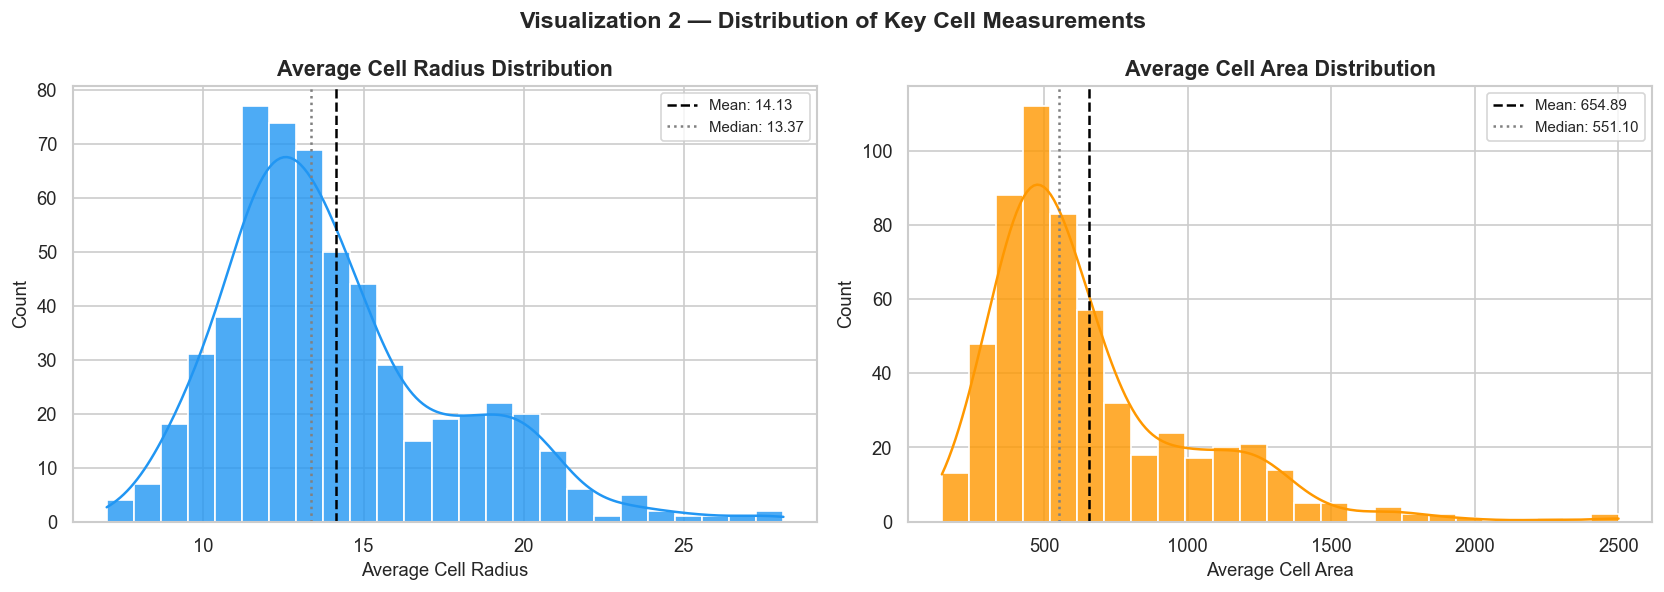

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visualization 2 — Distribution of Key Cell Measurements",
             fontsize=14, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    ('avg_cell_radius', 'Average Cell Radius', '#2196F3'),
    ('avg_cell_area',   'Average Cell Area',   '#FF9800')
]):
    sns.histplot(df[col], bins=25, kde=True,
                 color=color, ax=ax,
                 edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='black',
               linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='gray',
               linestyle=':', linewidth=1.5,
               label=f'Median: {df[col].median():.2f}')
    ax.set_title(f"{label} Distribution")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz2_histograms.png', bbox_inches='tight')
plt.show()

 # 📊 Section 2: Bivariate Analysis


# Visualization 3: Box Plots — Benign vs Malignant Box plots
 It show median, spread and outliers for each group.
 If the two boxes do not overlap — that feature is a strong indicator to distinguish cancer from non-cancer.
 Diamond marker shows the mean value for each group.

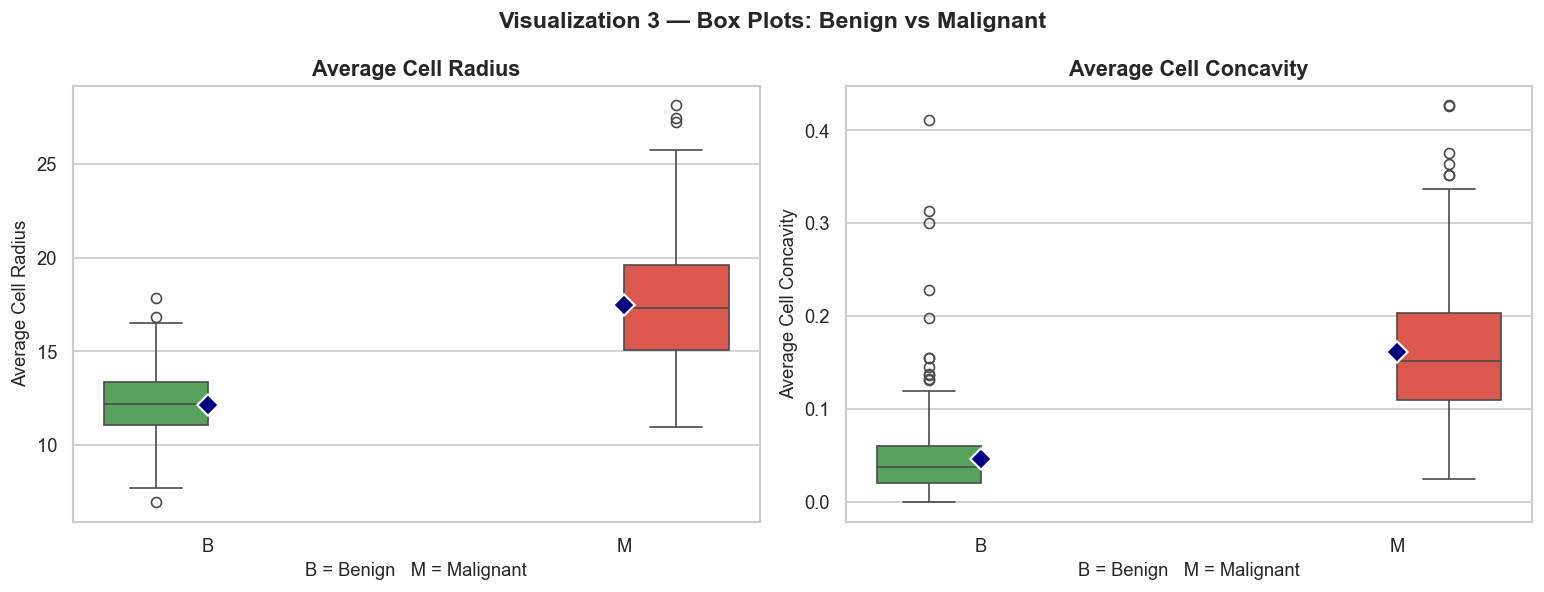

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Visualization 3 — Box Plots: Benign vs Malignant",
             fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('avg_cell_radius',    'Average Cell Radius'),
    ('avg_cell_concavity', 'Average Cell Concavity'),
]):
    sns.boxplot(data=df, x='cancer_type', y=col,
                hue='cancer_type',
                palette=COLORS, ax=ax,
                width=0.5, order=['B','M'],
                legend=False)
    ax.set_title(f"{label}")
    ax.set_xlabel("B = Benign   M = Malignant")
    ax.set_ylabel(label)
    for j, ct in enumerate(['B','M']):
        mean_val = df[df['cancer_type']==ct][col].mean()
        ax.plot(j, mean_val, 'D', color='white',
                markersize=9, zorder=5)
        ax.plot(j, mean_val, 'D', color='navy',
                markersize=7, zorder=6)

plt.tight_layout()
plt.savefig('viz3_boxplots.png', bbox_inches='tight')
plt.show()


# Visualization 5: Violin Plots — Distribution Shape
Violin plots combine a box plot with a density curve.
 The wider the violin at a value, the more patients have that measurement. This shows whether Benign and Malignant groups clearly separate or overlap.

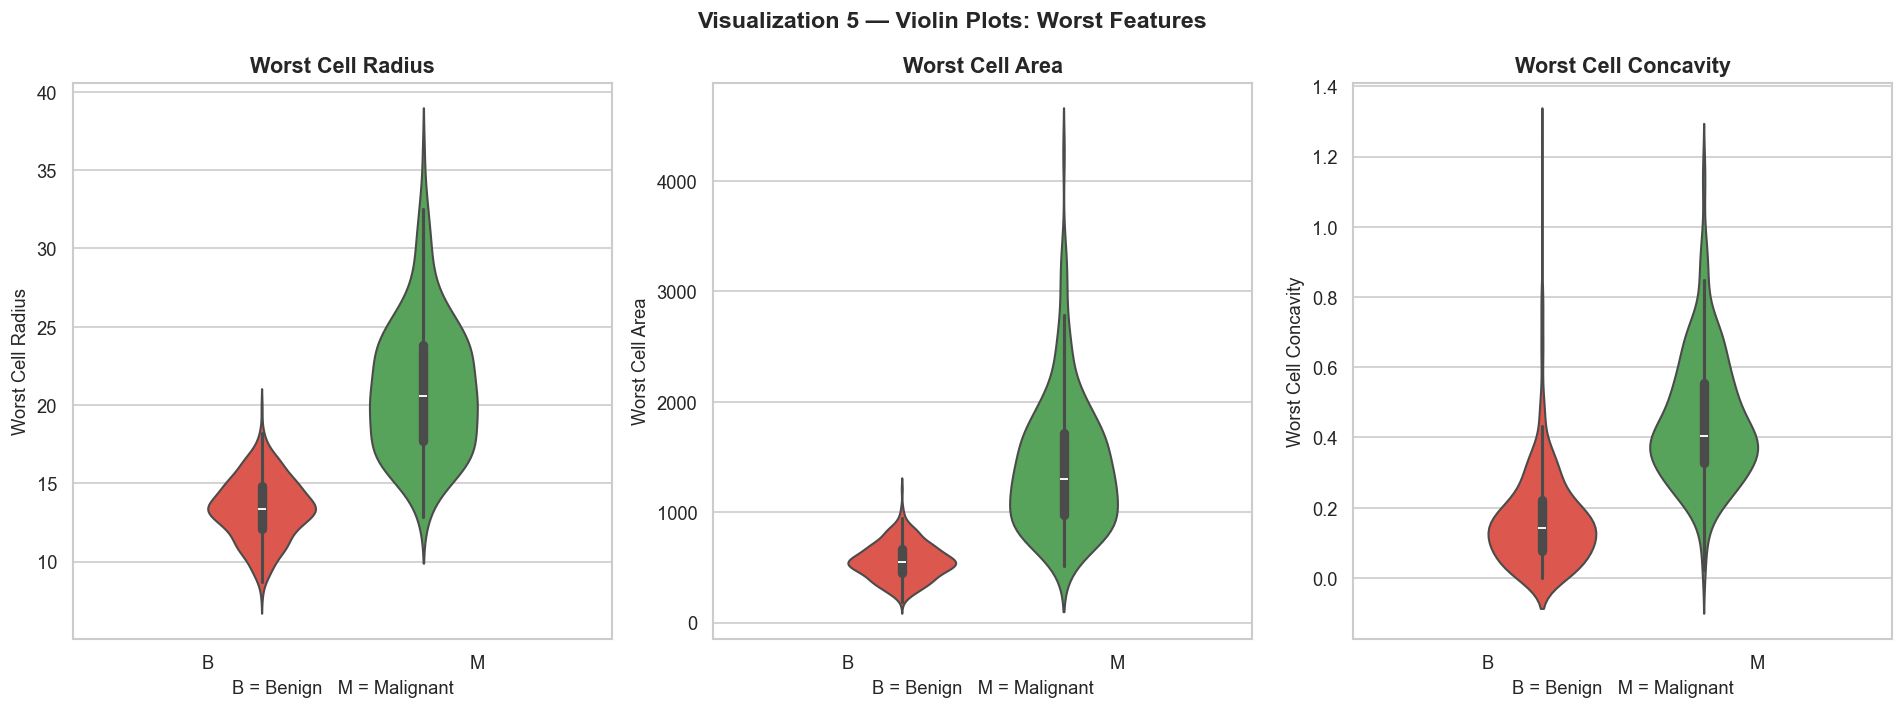

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Visualization 5 — Violin Plots: Worst Features",
             fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('worst_cell_radius',    'Worst Cell Radius'),
    ('worst_cell_area',      'Worst Cell Area'),
    ('worst_cell_concavity', 'Worst Cell Concavity'),
]):
    sns.violinplot(data=df, x='cancer_type', y=col,
                   hue='cancer_type',
                   palette=COLORS, ax=ax,
                   order=['B','M'],
                   legend=False, inner='box')
    ax.set_title(label)
    ax.set_xlabel("B = Benign   M = Malignant")
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('viz5_violin.png', bbox_inches='tight')
plt.show()


# Visualization 5: Scatter Plot — Cell Radius vs Cell Area
-- Scatter plots show the relationship between two numeric features.
--Colouring by cancer type reveals whether the two groups form separate clusters — a key signal that these featurescan be used to detect cancer.

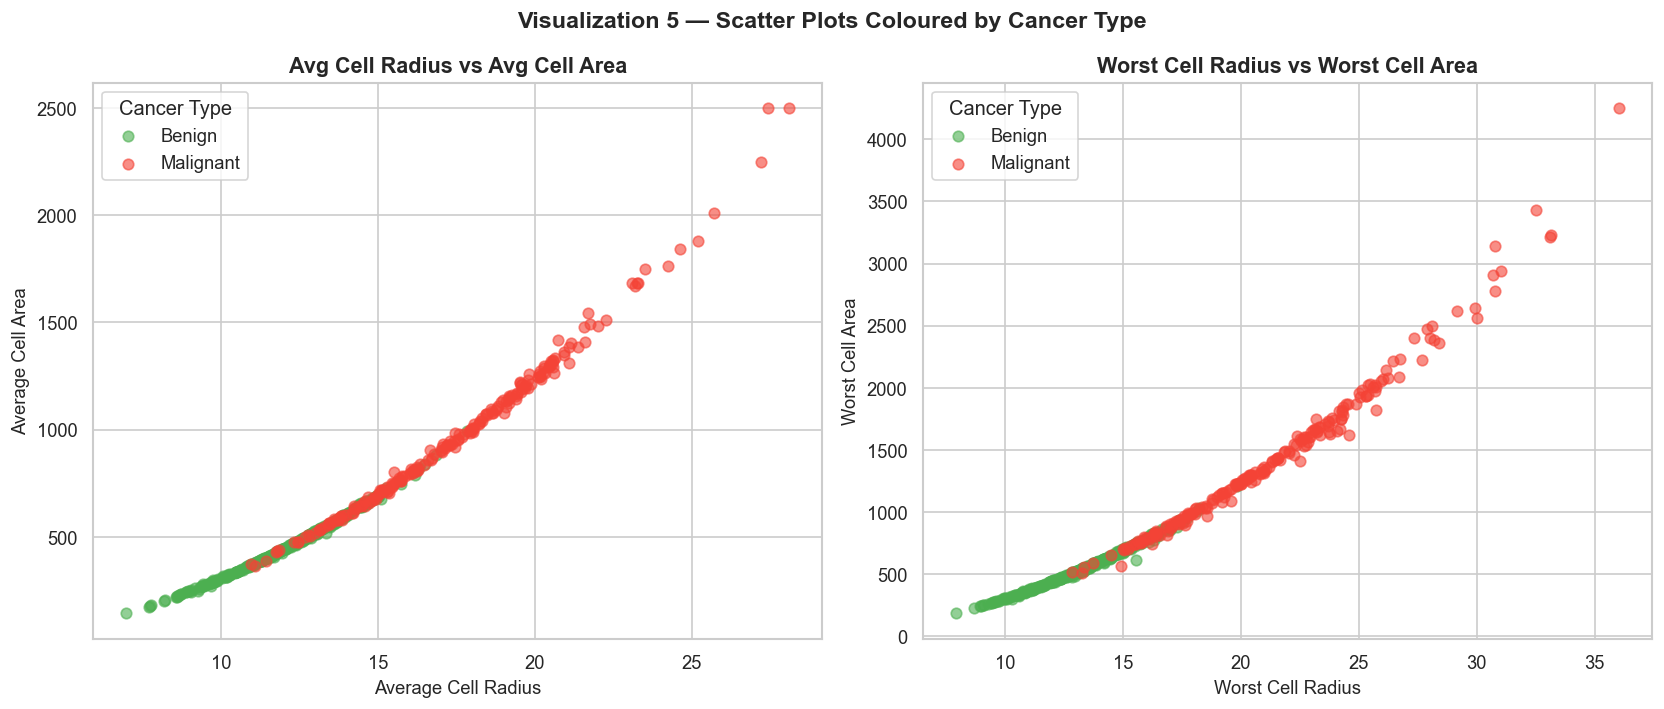

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Visualization 5 — Scatter Plots Coloured by Cancer Type",
             fontsize=14, fontweight='bold')

for ct, color in COLORS.items():
    subset = df[df['cancer_type'] == ct]
    label  = 'Benign' if ct == 'B' else 'Malignant'
    axes[0].scatter(subset['avg_cell_radius'],
                    subset['avg_cell_area'],
                    c=color, alpha=0.6, s=40, label=label)
    axes[1].scatter(subset['worst_cell_radius'],
                    subset['worst_cell_area'],
                    c=color, alpha=0.6, s=40, label=label)

axes[0].set_title("Avg Cell Radius vs Avg Cell Area")
axes[0].set_xlabel("Average Cell Radius")
axes[0].set_ylabel("Average Cell Area")
axes[0].legend(title='Cancer Type')

axes[1].set_title("Worst Cell Radius vs Worst Cell Area")
axes[1].set_xlabel("Worst Cell Radius")
axes[1].set_ylabel("Worst Cell Area")
axes[1].legend(title='Cancer Type')

plt.tight_layout()
plt.savefig('viz5_scatter.png', bbox_inches='tight')
plt.show()


📊 Section 3: Multivariate Analysis


#  Visualization 6: Correlation Heatmap
 Shows how strongly every pair of features is related to each other.
 Values close to 1.0 = strong relationship.
 Values close to 0.0 = no relationship.
 The last row shows which features are most linked to cancer diagnosis.

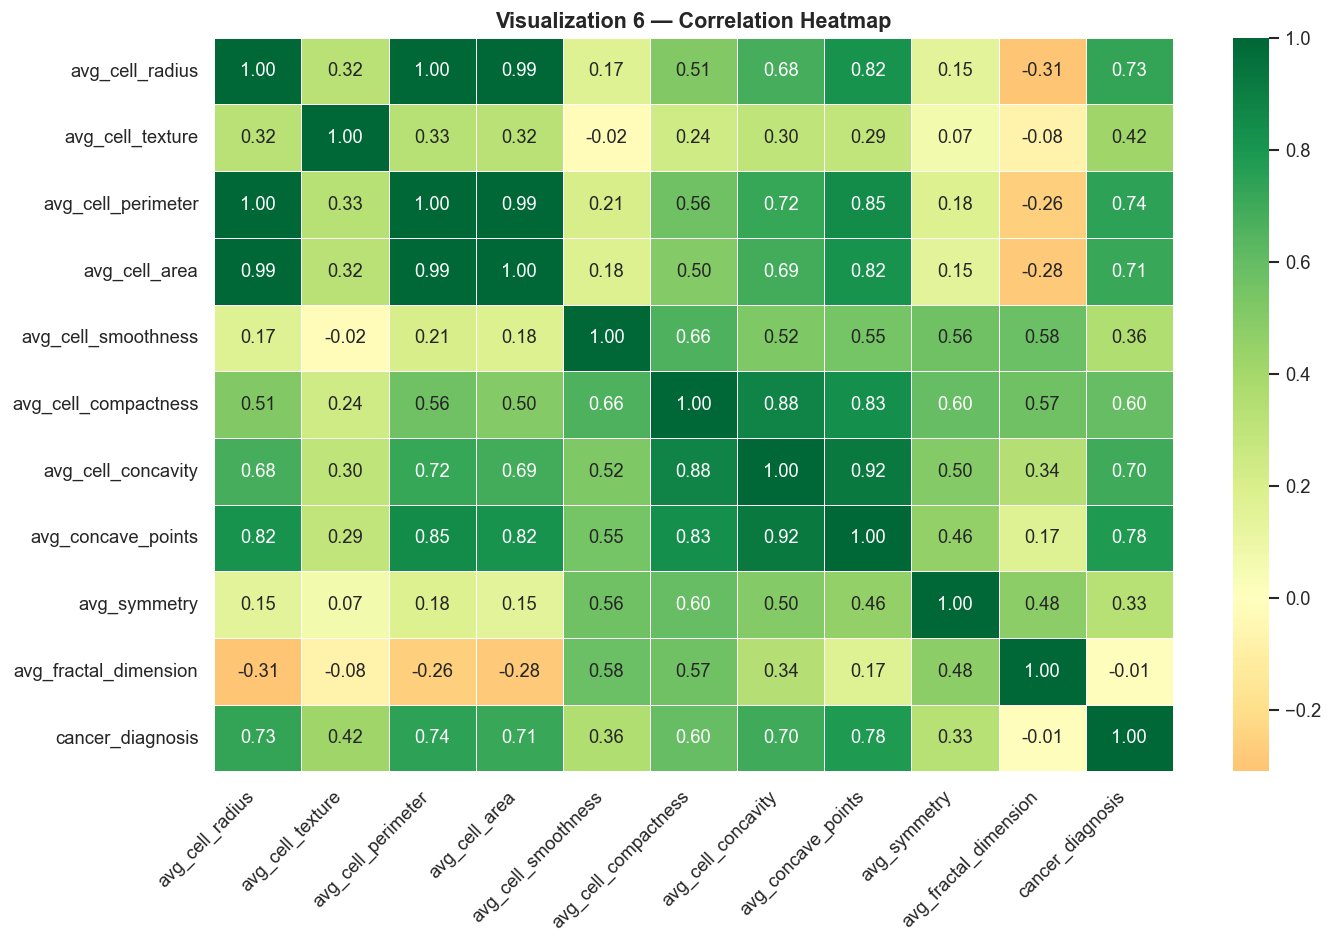

In [16]:
# Select only the avg_ columns + cancer diagnosis
selected_cols = avg_cols + ['cancer_diagnosis']

# Calculate correlation
corr = df[selected_cols].corr().round(2)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Visualization 6 — Correlation Heatmap",
             fontsize=13, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('viz6_heatmap.png', bbox_inches='tight')
plt.show()


# Visualization 7: Tumor Size vs Cancer Type
This stacked bar shows for each tumor size group how many patients are Benign and Malignant.
Larger tumors are expected to have higher malignancy confirming that early detection before tumors grow saves lives.s.

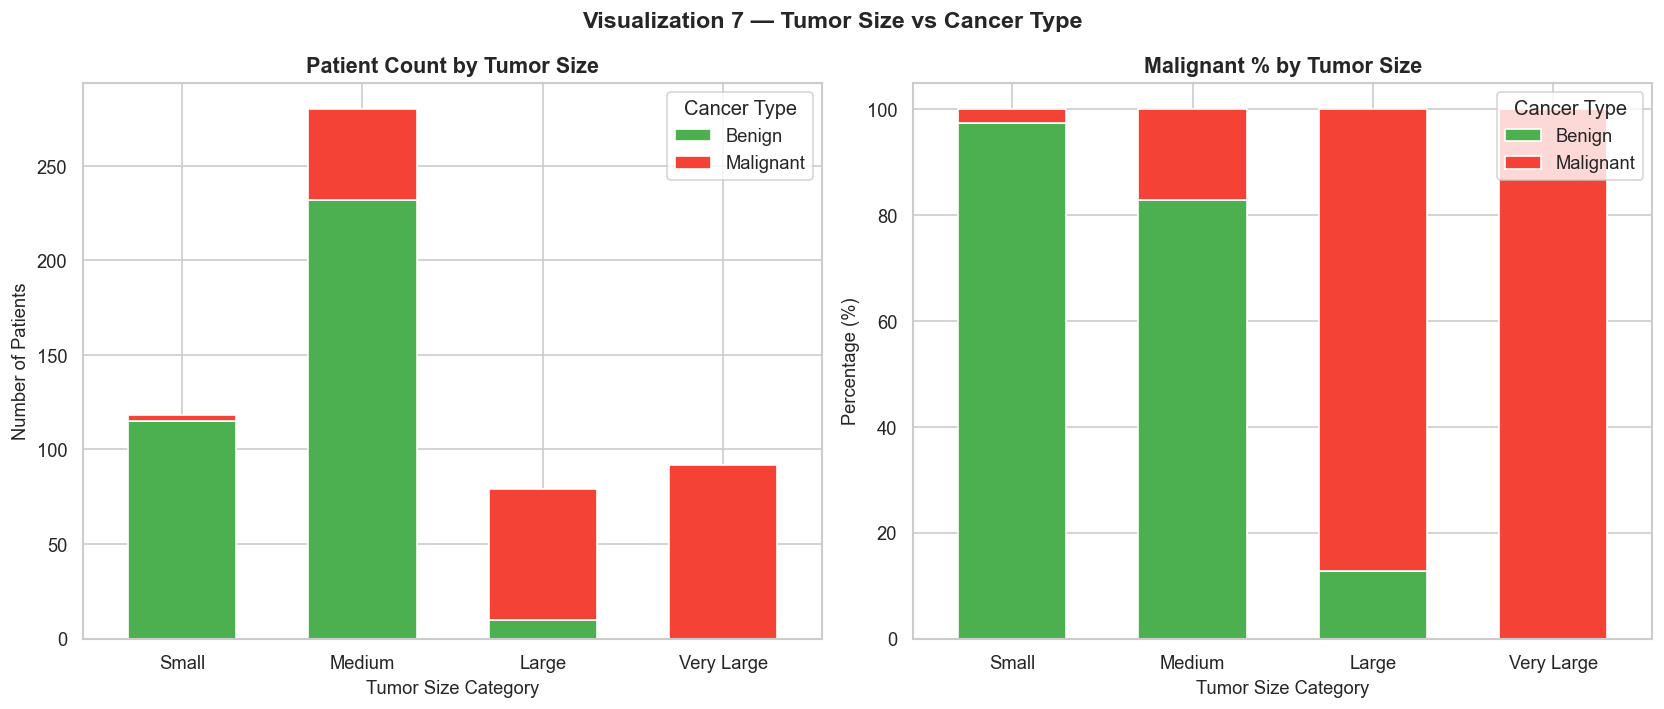

In [26]:
pivot = df.groupby(['tumor_size_category','cancer_type'],
                    observed=True)\
           .size().unstack(fill_value=0)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Visualization 7 — Tumor Size vs Cancer Type",
             fontsize=14, fontweight='bold')

pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#4CAF50','#F44336'],
           edgecolor='white', width=0.6)
axes[0].set_title("Patient Count by Tumor Size")
axes[0].set_xlabel("Tumor Size Category")
axes[0].set_ylabel("Number of Patients")
axes[0].legend(['Benign','Malignant'], title='Cancer Type')
axes[0].tick_params(axis='x', rotation=0)

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#4CAF50','#F44336'],
               edgecolor='white', width=0.6)
axes[1].set_title("Malignant % by Tumor Size")
axes[1].set_xlabel("Tumor Size Category")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(['Benign','Malignant'], title='Cancer Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('viz7_stackedbar.png', bbox_inches='tight')
plt.show()


📊 Section 4: Statistical Analysis

# Visualization 8: Feature Importance
 Ranks all features by how strongly they correlate with cancer diagnosis. Red bars = very strong predictors (>0.7), Orange = moderate (>0.5), Green = weaker predictors.
 This is the most important chart for medical insight.

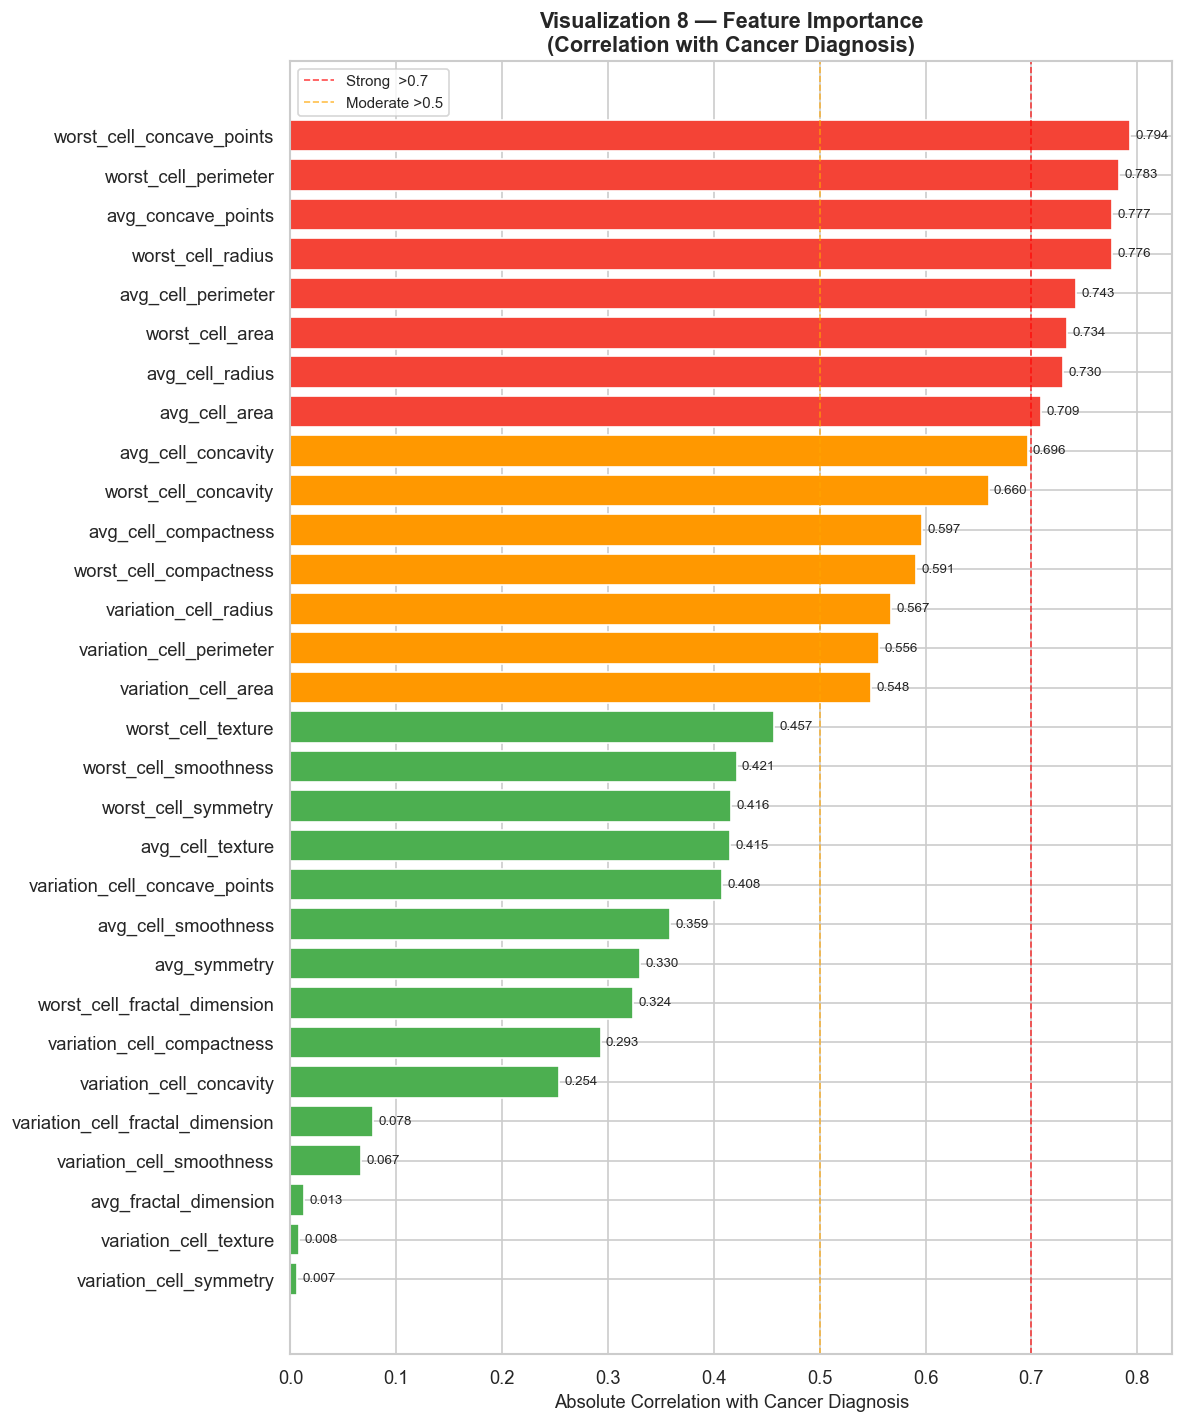

In [19]:
corr_with_diag = df[feature_cols + ['cancer_diagnosis']]\
    .corr()['cancer_diagnosis']\
    .drop('cancer_diagnosis')\
    .abs()\
    .sort_values()

colors_bar = ['#F44336' if v > 0.7 else
              '#FF9800' if v > 0.5 else
              '#4CAF50'
              for v in corr_with_diag]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(corr_with_diag.index,
               corr_with_diag.values,
               color=colors_bar, edgecolor='white')
ax.set_title(
    "Visualization 8 — Feature Importance\n"
    "(Correlation with Cancer Diagnosis)",
    fontsize=13, fontweight='bold')
ax.set_xlabel("Absolute Correlation with Cancer Diagnosis")
ax.axvline(0.7, color='red',    linestyle='--',
           linewidth=1, alpha=0.7, label='Strong  >0.7')
ax.axvline(0.5, color='orange', linestyle='--',
           linewidth=1, alpha=0.7, label='Moderate >0.5')
ax.legend(fontsize=9)
for bar, val in zip(bars, corr_with_diag.values):
    ax.text(val+0.005,
            bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('viz8_feature_importance.png', bbox_inches='tight')
plt.show()



# Visualization 9: Cancer Type Distribution Across Categories
Count plots show how Benign and Malignant cases are spread across different tumor size and smoothness groups.
This helps us understand whether larger or rougher tumors are more likely to be Malignant — a key clinical question.

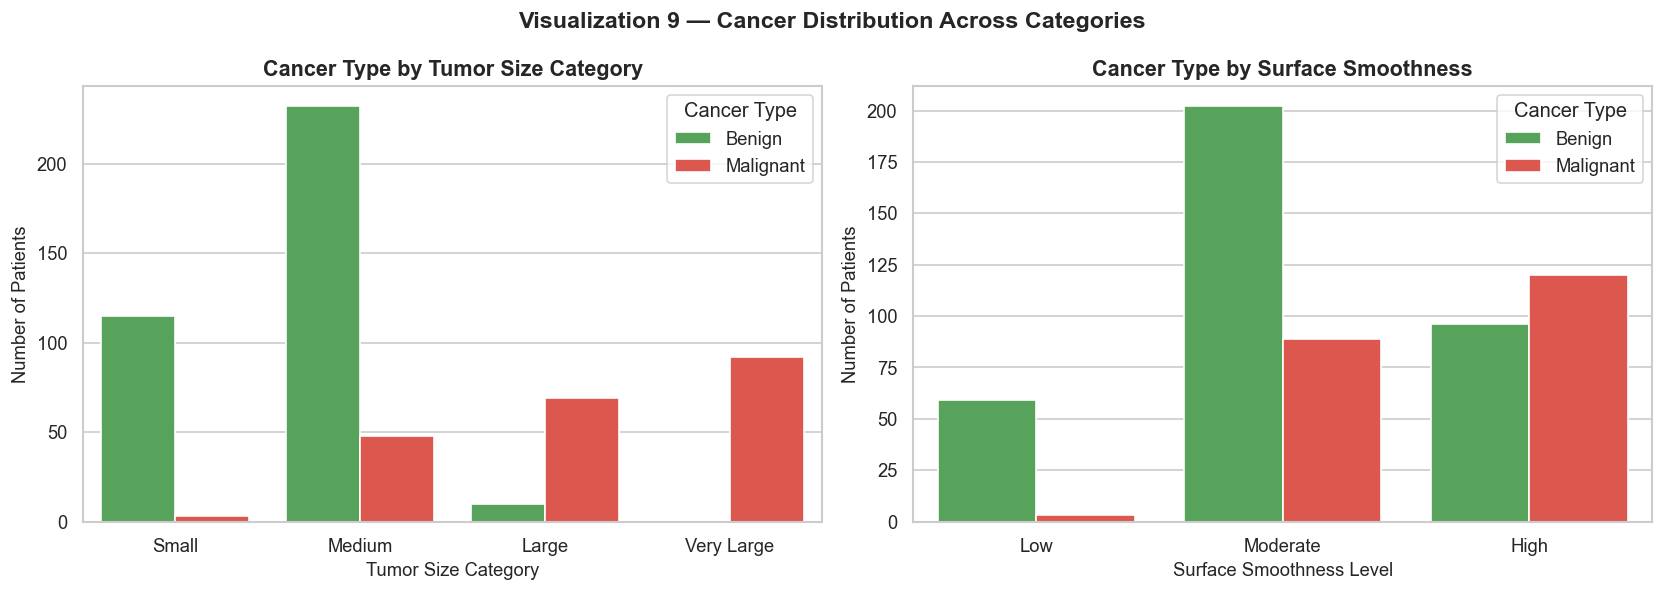

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visualization 9 — Cancer Distribution Across Categories",
             fontsize=14, fontweight='bold')

# Count plot 1 — tumor size
sns.countplot(data=df,
              x='tumor_size_category',
              hue='cancer_type',
              palette=COLORS,
              ax=axes[0],
              order=['Small','Medium','Large','Very Large'])
axes[0].set_title("Cancer Type by Tumor Size Category")
axes[0].set_xlabel("Tumor Size Category")
axes[0].set_ylabel("Number of Patients")
axes[0].legend(title='Cancer Type',
               labels=['Benign','Malignant'])

# Count plot 2 — surface smoothness
sns.countplot(data=df,
              x='surface_smoothness',
              hue='cancer_type',
              palette=COLORS,
              ax=axes[1],
              order=['Low','Moderate','High'])
axes[1].set_title("Cancer Type by Surface Smoothness")
axes[1].set_xlabel("Surface Smoothness Level")
axes[1].set_ylabel("Number of Patients")
axes[1].legend(title='Cancer Type',
               labels=['Benign','Malignant'])

plt.tight_layout()
plt.savefig('viz9_countplot.png', bbox_inches='tight')
plt.show()


#  Visualization 10: Growth Factors — Benign vs Malignant
These are derived features created in Stage 1.
radius_growth_factor = worst_cell_radius ÷ avg_cell_radius.
A higher value means the tumor grew much larger in its worst state compared to average — a strong sign of malignancy.

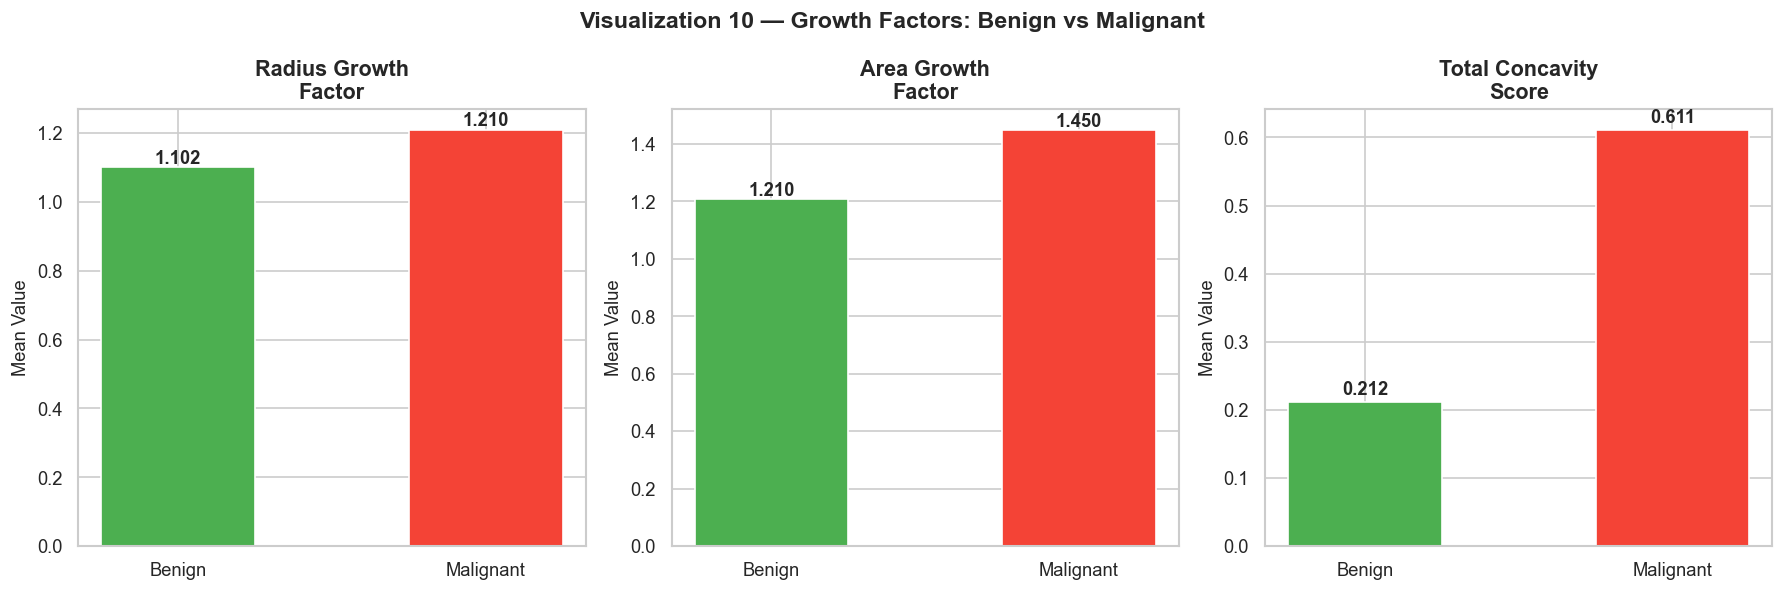

In [22]:
growth_cols  = ['radius_growth_factor',
                'area_growth_factor',
                'total_concavity_score']

growth_means = df.groupby('cancer_type',
                observed=True)[growth_cols].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Visualization 10 — Growth Factors: Benign vs Malignant",
             fontsize=14, fontweight='bold')

titles = ['Radius Growth\nFactor',
          'Area Growth\nFactor',
          'Total Concavity\nScore']

for ax, col, title in zip(axes, growth_cols, titles):
    vals = [growth_means.loc['B', col],
            growth_means.loc['M', col]]
    bars = ax.bar(['Benign','Malignant'], vals,
                  color=['#4CAF50','#F44336'],
                  edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_ylabel("Mean Value")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.savefig('viz10_growth_factors.png', bbox_inches='tight')
plt.show()

# 💡Key Insights & Findings

----


### 🔑 Insight 1: Malignant Tumors Are Significantly Larger

From **Visualization 3 (Box Plots)** and **Visualization 10 (Growth Factors)**,
Malignant tumors have a much higher average cell radius (mean = 17.46)
compared to Benign tumors (mean = 12.15).

The `radius_growth_factor` is also significantly higher in Malignant
tumors — meaning cancerous cells not only start larger but also grow
much more aggressively to their worst recorded state.

**Medical meaning:** Tumor size is one of the earliest and strongest
warning signs of cancer. A cell nucleus that is significantly larger
than normal should immediately be investigated further.

---

### 🔑 Insight 2: Cell Concavity Best Predicts Cancer

From **Visualization 8 (Feature Importance)**, `worst_concave_points`
and `avg_concave_points` have the highest correlation with cancer
diagnosis — above 0.77 and 0.79 respectively. These are the
strongest predictors out of all 30 features.

**Medical meaning:** Malignant tumor cells have far more dents and
irregular borders compared to Benign cells. A smooth round cell is
likely Benign — a deeply dented irregular cell is likely Malignant.
This can be detected directly from microscope images without any
invasive procedure — making it extremely valuable for early diagnosis.

---

### 🔑 Insight 3: Radius, Area and Perimeter Are Almost Perfectly Correlated

From **Visualization 6 (Correlation Heatmap)**, `avg_cell_radius`,
`avg_cell_area` and `avg_cell_perimeter` show correlation values
above 0.99 with each other — almost perfectly correlated.

**Medical meaning:** This makes mathematical sense — a larger radius
automatically means a larger area and longer perimeter. This tells
doctors that measuring just one of these three features is enough
to capture all three — reducing the time and cost of diagnosis
without losing any diagnostic information.

---

### 🔑 Insight 4: Larger Tumors Have Higher Malignancy Rate

From **Visualization 7 (Stacked Bar)** and **Visualization 9 (Count Plot)**,
as tumor size increases from Small → Medium → Large → Very Large,
the proportion of Malignant cases steadily increases.

Very Large tumors show the highest percentage of Malignant diagnoses
compared to Small tumors which are mostly Benign.

**Medical meaning:** This confirms the well-known clinical fact that
early detection saves lives. When a tumor is still Small in size,
it is much more likely to be Benign and treatable. Waiting until
the tumor becomes Very Large significantly increases the risk of
it being Malignant and harder to treat.

---

### 🔑 Insight 5: Dataset Is Moderately Imbalanced

From **Visualization 1 (Pie Chart)**, 357 out of 569 patients
(62.7%) have Benign tumors and 212 (37.3%) have Malignant tumors.

**Medical meaning:** This reflects real world clinical reality —
not every patient who comes in for a biopsy has cancer. However
this imbalance is important to note because any future machine
learning model built on this data must account for this imbalance
to avoid being biased toward always predicting Benign.
For our EDA all comparisons were done proportionally between
both groups to ensure fair and accurate conclusions.

---

## 📝 Conclusion & Recommendations

### Summary of Key Findings

| # | Finding | Key Feature | Observation |
|---|---------|-------------|-------------|
| 1 | Tumor size | avg_cell_radius | Malignant = 44% larger than Benign |
| 2 | Shape irregularity | avg_concave_points | Strongest cancer predictor (r = 0.78) |
| 3 | Feature redundancy | radius, area, perimeter | 99%+ correlated — one is enough |
| 4 | Size vs malignancy | tumor_size_category | Larger size = higher malignancy rate |
| 5 | Dataset balance | cancer_type | 62.7% Benign vs 37.3% Malignant |

### Recommendations & Next Steps

1. **Early Screening** — Since cell concavity and size are the
   strongest indicators, hospitals should prioritize measuring
   these features during routine breast cancer screenings.

2. **Build a Prediction Model** — The clear separation between
   Benign and Malignant groups seen in scatter plots and box plots
   confirms this dataset is ideal for building a machine learning
   classification model to automate cancer detection.

3. **Focus on Worst Features** — The worst_ columns showed even
   stronger separation than mean values — recording the most
   extreme cell measurement is more diagnostically valuable
   than just recording averages.

4. **Reduce Feature Redundancy** — Since radius, area and
   perimeter are 99% correlated, future analysis should use
   only one of these three to avoid redundancy and improve
   model efficiency.

---

**Dataset:** Breast Cancer Wisconsin (Diagnostic)
**Source:** UCI Machine Learning Repository
**URL:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
**Citation:** Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993).
UCI ML Repository. https://doi.org/10.24432/C5DW2B